# Section E: Outlier Detection

In [ ]:
import pandas as pd 

In [ ]:
df  = pd.read_csv(r"D:\data-science-journey\Data_Science\Data\Flight_Booking_Advanced_Dirty_Dataset_5500_Records.csv")

In [ ]:
#  Find minimum ,max & mean Age
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

df['Age'].min()
df['Age'].max()
df['Age'].mean()

In [ ]:
#   Find minimum ,max & mean TicketPrice
df['TicketPrice'].min()
df['TicketPrice'].max()
df['TicketPrice'].mean()

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR_Age  = Q1 - Q3

lower = Q1 - 1.5* IQR_Age
upper = Q1 +  1.5* IQR_Age

df[(df['Age'] < lower) | (df['Age'] > upper)]

In [ ]:
# Display passengers with Age > 100. 
df[df['Age'] > 100]

In [ ]:
df[df['Age']< 0 ]

In [ ]:
# Display unusually high TicketPrice values.   
Q1 = df['TicketPrice'].quantile(0.25)
Q3 = df['TicketPrice'].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

df[df['TicketPrice'] > upper]


In [ ]:
# Display negative TicketPrice values. 

df[df['TicketPrice'] < 0]

In [ ]:
import matplotlib.pyplot as plt 

In [ ]:
# Create boxplot for Age. 
plt.boxplot(df['Age'].dropna())

plt.xlabel('Age')
plt.ylabel('Age')
plt.title('Boxplot of Age')
plt.grid()
plt.show()


In [ ]:
# Create boxplot for TicketPrice.

plt.figure(figsize=(10, 6))
plt.boxplot(df['TicketPrice'].dropna())

plt.xlabel('TicketPrice')
plt.ylabel('TicketPrice')
plt.title('Boxplot of TicketPrice')
plt.grid()
plt.show()


In [ ]:
# Calculate quartiles of Age. 
Q1 = df['Age'].quantile(0.25)
Q2 = df['Age'].quantile(0.50)
Q3 = df['Age'].quantile(0.75)

print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)

In [ ]:
# Calculate IQR for Age. 

IQR_Age 

In [ ]:
# Calculate IQR for TicketPrice. 

IQR

In [ ]:
# Remove outlier ages.   
df = df[df['Age'].between(0, 100)]

In [ ]:
# Remove outlier ticket prices. 
df = df[df['TicketPrice'] <= upper]

In [ ]:
# Count total outliers.     
total_outliers = 0

for col in ['Age', 'TicketPrice']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    total_outliers += ((df[col] < lower) | (df[col] > upper)).sum()

print("Total Outliers:", total_outliers)

In [ ]:
# Display top 20 outlier records.  
total_outliers = 0

for col in ['Age', 'TicketPrice']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR


df[(df[col] < lower) | (df[col] > upper)]
# print("Total Outliers:", total_outliers)

In [75]:
# 176. Export outlier records

Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

Q1_price = df['TicketPrice'].quantile(0.25)
Q3_price = df['TicketPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

outliers = df[
    (df['Age'] < lower_age) |
    (df['Age'] > upper_age) |
    (df['TicketPrice'] < lower_price) |
    (df['TicketPrice'] > upper_price)
]

outliers.to_csv(r"D:\data-science-journey\Data_Science\03_Bacis_modules_for_ML\Flight_Booking_Analiysis\CSV_File_sectionWise\outlier_records.csv", index=False)

In [78]:
# Create outlier summary report

summary = pd.DataFrame({
    'Column': ['Age', 'TicketPrice'],
    'Lower Limit': [lower_age, lower_price],
    'Upper Limit': [upper_age, upper_price],
    'Outlier Count': [
        ((df['Age'] < lower_age) |
         (df['Age'] > upper_age)).sum(),

        ((df['TicketPrice'] < lower_price) |
         (df['TicketPrice'] > upper_price)).sum()
    ]
})

print(summary)

        Column  Lower Limit  Upper Limit  Outlier Count
0          Age      -10.000      102.000              0
1  TicketPrice   -37452.875   112710.125             21


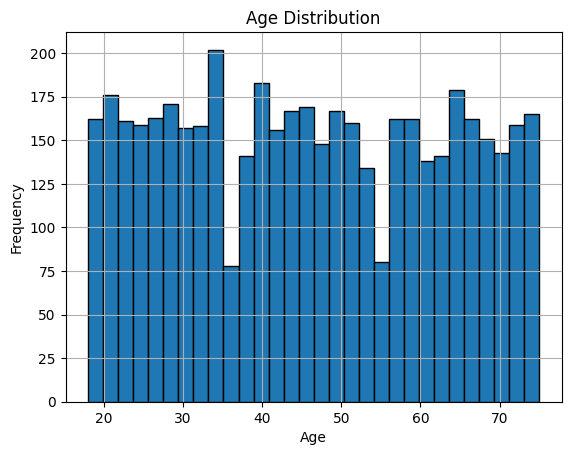

In [81]:
# Create histogram for Age
import matplotlib.pyplot as plt

plt.hist(df['Age'], bins=30,edgecolor = 'black')

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.grid()
plt.show()

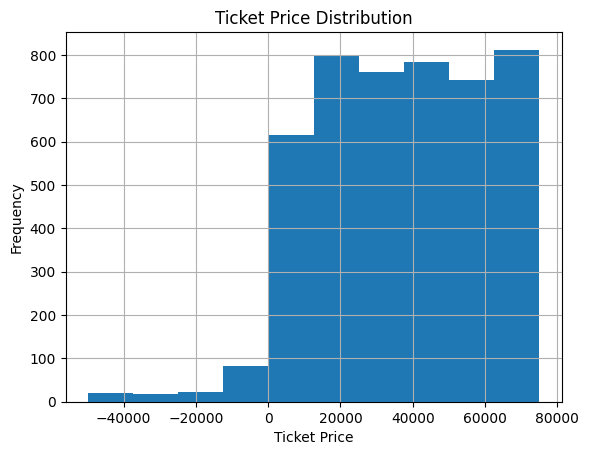

In [ ]:
plt.hist(df['TicketPrice'], bins=10)

plt.xlabel('Ticket Price')
plt.ylabel('Frequency')
plt.title('Ticket Price Distribution')
plt.grid()
plt.show()